### Poisson Model

In [12]:
# IMPORTS FOR WHOLE FILE
import pandas as pd        
import numpy as np           
import xgboost as xg
import sklearn            
from scipy.stats import norm   


RISK METRICS

In [13]:
def performance_metrics(results, bankroll_start):
    
    final_bankroll = results["Bankroll"].iloc[-1]
    total_return = (final_bankroll - bankroll_start) / bankroll_start
    
    bet_mask = results["Stake"] > 0
    total_bets = bet_mask.sum()
    
    wins = (results.loc[bet_mask, "Profit"] > 0).sum()
    losses = (results.loc[bet_mask, "Profit"] < 0).sum()
    
    win_rate = wins / total_bets if total_bets > 0 else 0
    
    return {
        "Final Bankroll": round(final_bankroll, 2),
        "Total Return (%)": round(total_return * 100, 2),
        "Total Bets": int(total_bets),
        "Wins": int(wins),
        "Losses": int(losses),
        "Win Rate (%)": round(win_rate * 100, 2)
    }

def bankroll_returns(results):
    return results["Bankroll"].pct_change().fillna(0)

def distribution_metrics(results):
    
    returns = bankroll_returns(results)
    
    skewness = returns.skew()
    kurtosis = returns.kurtosis()
    
    return {
        "Skewness": round(skewness, 4),
        "Kurtosis": round(kurtosis, 4)
    }
def drawdown_metrics(results, bankroll_start):
    
    wealth = results["Bankroll"]
    rolling_max = wealth.cummax()
    drawdown = (wealth - rolling_max) / rolling_max
    
    max_drawdown = drawdown.min()
    
    total_return = (wealth.iloc[-1] - bankroll_start) / bankroll_start
    calmar = total_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    underwater = 0
    max_underwater = 0
    
    for dd in drawdown:
        if dd < 0:
            underwater += 1
            max_underwater = max(max_underwater, underwater)
        else:
            underwater = 0
    
    return {
        "Max Drawdown (%)": round(max_drawdown * 100, 2),
        "Calmar Ratio": round(calmar, 4),
        "Max Time Under Water (periods)": int(max_underwater)
    }

def streak_metrics(results):
    
    bet_mask = results["Stake"] > 0
    profits = results.loc[bet_mask, "Profit"]
    
    losing_streak = 0
    max_losing_streak = 0
    
    for pnl in profits:
        if pnl < 0:
            losing_streak += 1
            max_losing_streak = max(max_losing_streak, losing_streak)
        else:
            losing_streak = 0
    
    return {
        "Longest Losing Streak": int(max_losing_streak)
    }


def ratio_metrics(results):
    
    returns = bankroll_returns(results)
    
    mean_return = returns.mean()
    volatility = returns.std()
    
    sharpe = mean_return / volatility if volatility != 0 else 0
    
    downside = returns[returns < 0]
    downside_std = downside.std()
    sortino = mean_return / downside_std if downside_std != 0 else 0
    
    return {
        "Volatility": round(volatility, 6),
        "Sharpe Ratio": round(sharpe, 4),
        "Sortino Ratio": round(sortino, 4)
    }


def run_metrics(results, bankroll_start):
    
    print("----- PERFORMANCE -----")
    perf = performance_metrics(results, bankroll_start)
    for k, v in perf.items():
        print(f"{k}: {v}")
    
    print("\n----- RATIOS -----")
    ratios = ratio_metrics(results)
    for k, v in ratios.items():
        print(f"{k}: {v}")
    
    print("\n----- DISTRIBUTION -----")
    dist = distribution_metrics(results)
    for k, v in dist.items():
        print(f"{k}: {v}")
    
    print("\n----- DRAWDOWN -----")
    dd = drawdown_metrics(results, bankroll_start)
    for k, v in dd.items():
        print(f"{k}: {v}")
    
    print("\n----- STREAKS -----")
    streak = streak_metrics(results)
    for k, v in streak.items():
        print(f"{k}: {v}")

PlOTS

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
def plot_equity_curve(results):
    
    plt.figure()
    plt.plot(results["Bankroll"].values)
    plt.title("Equity Curve")
    plt.xlabel("Match Number")
    plt.ylabel("Bankroll")
    plt.show()

def plot_drawdown(results):
    
    wealth = results["Bankroll"]
    rolling_max = wealth.cummax()
    drawdown = (wealth - rolling_max) / rolling_max
    
    plt.figure()
    plt.plot(drawdown.values)
    plt.title("Drawdown")
    plt.xlabel("Match")
    plt.ylabel("Drawdown")
    plt.show()

def plot_rolling_sharpe(results, window=50):
    
    returns = results["Bankroll"].pct_change().fillna(0)
    rolling_mean = returns.rolling(window).mean()
    rolling_std = returns.rolling(window).std()
    rolling_sharpe = rolling_mean / rolling_std
    
    plt.figure()
    plt.plot(rolling_sharpe.values)
    plt.title("Rolling Sharpe")
    plt.xlabel("Match")
    plt.ylabel("Sharpe")
    plt.show()

def plot_edge_histogram(results):
    
    edges = results["Edge"]
    
    plt.figure()
    plt.hist(edges, bins=30)
    plt.title("Edge Distribution")
    plt.xlabel("Edge")
    plt.ylabel("Frequency")
    plt.show()

def plot_profit_by_edge_bucket(results, buckets=10):
    
    df = results.copy()
    
    df = df[df["Stake"] > 0]  # Only actual bets
    
    df["Edge_Bucket"] = pd.qcut(df["Edge"], q=buckets, duplicates="drop")
    
    grouped = df.groupby("Edge_Bucket")["Profit"].mean()
    
    plt.figure()
    grouped.plot(kind="bar")
    plt.title("Average Profit by Edge Bucket")
    plt.xlabel("Edge Bucket")
    plt.ylabel("Average Profit")
    plt.xticks(rotation=45)
    plt.show()

def plot_bet_frequency(results, window=50):
    
    bets = (results["Stake"] > 0).astype(int)
    rolling_bets = bets.rolling(window).mean()
    
    plt.figure()
    plt.plot(rolling_bets.values)
    plt.title("Rolling Bet Frequency")
    plt.xlabel("Match")
    plt.ylabel("Proportion of Bets")
    plt.show()
    
def plot_feature_importance(model, features):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    feat_imp.plot(kind='barh')
    plt.title("XGBoost Rolling Feature Importance")
    plt.xlabel("Importance Score")
    plt.show()

def plot_3d_parameter_surface(data, probability_function):

    kelly_scales = np.linspace(0.1, 0.4, 4) 
    min_edges = np.linspace(0.01, 0.04, 4)
    
    Z = np.zeros((len(kelly_scales), len(min_edges)))
    
    for i, k in enumerate(kelly_scales):
        for j, e in enumerate(min_edges):
            # Calls your fixed backtest
            sim_results = backtest(
                data,
                probability_function,
                bankroll_start=10000,
                kelly_scale=k,
                min_edge=e,
                max_fraction=0.05
            )
            Z[i, j] = sim_results["Bankroll"].iloc[-1]
    
    K, E = np.meshgrid(kelly_scales, min_edges)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(K, E, Z.T, cmap='viridis')
    
    ax.set_xlabel("Kelly Scale")
    ax.set_ylabel("Min Edge")
    ax.set_zlabel("Final Bankroll")
    plt.title("Strategy Sensitivity Surface")
    plt.show()

def run_plots_integrated(results, bankroll_start=10000, window=50):
    print("\n----- FEATURE IMPORTANCE -----")

    plot_feature_importance(model_home, features)

    print("\n----- EQUITY CURVE -----")
    plot_equity_curve(results)
    
    print("\n----- DRAWDOWN -----")
    plot_drawdown(results)
    
    print("\n----- ROLLING SHARPE -----")
    plot_rolling_sharpe(results, window=window)
    
    print("\n----- EDGE DISTRIBUTION -----")
    plot_edge_histogram(results)
    
    print("\n----- PROFIT BY EDGE BUCKET -----")
    plot_profit_by_edge_bucket(results)
    
    print("\n----- BET FREQUENCY -----")
    plot_bet_frequency(results, window=window)

DATA CLEANING

In [15]:
df = pd.read_csv('data/nba_team_reference.csv')
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values('game_date')

# 2. FEATURE ENGINEERING: ROLLING AVERAGES
# We need to see every team performance in one column to calculate "Last 10"
home_df = df[['game_date', 'season_year', 'team_id_home', 'pts_home', 'pts_away']].rename(
    columns={'team_id_home': 'team_id', 'pts_home': 'pts_scored', 'pts_away': 'pts_allowed'})
away_df = df[['game_date', 'season_year', 'team_id_away', 'pts_away', 'pts_home']].rename(
    columns={'team_id_away': 'team_id', 'pts_away': 'pts_scored', 'pts_home': 'pts_allowed'})

all_perf = pd.concat([home_df, away_df]).sort_values(['team_id', 'game_date'])

# rolling averages per team per season
window = 10
all_perf = all_perf.sort_values(['team_id', 'game_date']) # CRITICAL
all_perf['roll_off'] = all_perf.groupby(['season_year', 'team_id'])['pts_scored'].transform(lambda x: x.rolling(window, min_periods=3).mean().shift(1)) #prevents the model from knowing the current game's score
all_perf['roll_def'] = all_perf.groupby(['season_year', 'team_id'])['pts_allowed'].transform(lambda x: x.rolling(window, min_periods=3).mean().shift(1))

# back to the main df
df = df.merge(all_perf[['game_date', 'team_id', 'roll_off', 'roll_def']], 
              left_on=['game_date', 'team_id_home'], right_on=['game_date', 'team_id'], how='left').rename(
              columns={'roll_off': 'home_offense', 'roll_def': 'home_defense'}).drop(columns='team_id')

df = df.merge(all_perf[['game_date', 'team_id', 'roll_off', 'roll_def']], 
              left_on=['game_date', 'team_id_away'], right_on=['game_date', 'team_id'], how='left').rename(
              columns={'roll_off': 'away_offense', 'roll_def': 'away_defense'}).drop(columns='team_id')

df = df.dropna(subset=['home_offense', 'away_offense'])


TRAIN MODEL

In [16]:
all_teams = pd.unique(df[['team_abbreviation_home', 'team_abbreviation_away']].values.ravel())
df['team_abbreviation_home'] = pd.Categorical(df['team_abbreviation_home'], categories=all_teams)
df['team_abbreviation_away'] = pd.Categorical(df['team_abbreviation_away'], categories=all_teams)

features = ["team_abbreviation_home", "team_abbreviation_away", "home_offense", "home_defense", "away_offense", "away_defense"]
X = df[features]
y_h = df['pts_home']
y_a = df['pts_away']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_h, y_test_h = y_h.iloc[:split_idx], y_h.iloc[split_idx:]
y_train_a, y_test_a = y_a.iloc[:split_idx], y_a.iloc[split_idx:]

model_params = {
    'objective': 'count:poisson',
    'n_estimators': 200,
    'learning_rate': 0.05,
    'max_depth': 4,
    'enable_categorical': True,
    'base_score': np.log(y_train_h.mean())
}

#find lamdas by averaging the number of points scored 
model_home = xg.XGBRegressor(**model_params)
model_away = xg.XGBRegressor(**model_params)

model_home.fit(X_train, y_train_h)
model_away.fit(X_train, y_train_a)





XGBRegressor(base_score=np.float64(4.7255142878341525), booster=None,
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, objective='count:poisson', ...)

HELPER FUNCTIONS

In [17]:
def calculate_edge(p, odds):
    return p - (1 / odds)

def kelly_fraction(p, d_odds, fraction=0.25):
    n_odds = d_odds - 1
    q = 1 - p 
    return max(((n_odds * p - q) * fraction / n_odds), 0)

def choose_bet(probabilities, odds, bankroll, kelly_scale, min_edge, max_fraction, max_bet=500):
    best_choice, best_stake = None, 0
    
    for outcome in ["Home", "Away"]:
        p = float(probabilities[outcome]) # Model Probability
        o = float(odds[outcome])          # Bookie Odds

        edge = calculate_edge(p,o)
        
        if edge > min_edge:
            kelly = kelly_fraction(p,o)
            
            if kelly > 0:
                stake = min(min(kelly_scale * kelly, max_fraction) * bankroll,max_bet)
                
                if stake > best_stake:
                    best_choice = outcome
                    best_stake = stake
                    
    return {"Decision": f"Bet {best_choice}" if best_choice else "No Bet", 
            "Stake (Coins)": round(float(best_stake), 2)}


def win_prob(lambda_home, lambda_away):
    #poisson(l1) - Poisson(l2) is approx Normal(mean=l1-l2, var=l1+l2)
    #this speeds up calculations
    mu = lambda_home - lambda_away
    sigma = np.sqrt(lambda_home + lambda_away)
    return 1 - norm.cdf(0, loc=mu, scale=sigma)

def poisson_probability_function(row):
    if 'lambda_h' in row and 'lambda_a' in row:
        lh = row['lambda_h']
        la = row['lambda_a']
    else:
        input_df = pd.DataFrame([row])
        input_df['team_abbreviation_home'] = pd.Categorical(input_df['team_abbreviation_home'], categories=all_teams)
        input_df['team_abbreviation_away'] = pd.Categorical(input_df['team_abbreviation_away'], categories=all_teams)
        
        lh = model_home.predict(input_df[features])[0]
        la = model_away.predict(input_df[features])[0]

    p_home = win_prob(lh, la)
    return {"Home": p_home, "Away": 1 - p_home, "Draw": 0.0}


BACKTESTING

In [18]:
def backtest(data, probability_function, bankroll_start=10000, kelly_scale=0.5, min_edge=0.02, max_fraction=0.05):
    data = data.reset_index(drop=True)
    bankroll, history = bankroll_start, []
    
    for i, row in data.iterrows():
        probs = probability_function(row)
        odds = {"Home": row.get("B365H", 2), "Draw": 999, "Away": row.get("B365A",2)}  # assume we have a 50:50 chance
        decision = choose_bet(probs, odds, bankroll, kelly_scale, min_edge, max_fraction)
        
        stake, profit, edge_used = 0, 0, 0
        if decision["Decision"] != "No Bet":
            outcome = decision["Decision"].split()[1]
            stake = decision["Stake (Coins)"]
            edge_used = calculate_edge(probs[outcome], odds[outcome])
            bankroll -= stake
            if (row["home_win"] == 1 and outcome == "Home") or (row["home_win"] == 0 and outcome == "Away"):
                profit = stake * (odds[outcome] - 1)
                bankroll += (stake + profit)
            else:
                profit = -stake
        
        history.append({"Bankroll": bankroll, "Stake": stake, "Profit": profit, "Edge": edge_used})
    return pd.DataFrame(history)

df_test_final = X_test.copy()
df_test_final['home_win'] = (df.iloc[split_idx:]['pts_home'] > df.iloc[split_idx:]['pts_away']).astype(int)
df_test_final['lambda_h'] = model_home.predict(df_test_final[features])
df_test_final['lambda_a'] = model_away.predict(df_test_final[features])
results = backtest(df_test_final, poisson_probability_function)


TEST MODEL

----- PERFORMANCE -----
Final Bankroll: 191592.99
Total Return (%): 1815.93
Total Bets: 1450
Wins: 913
Losses: 537
Win Rate (%): 62.97

----- RATIOS -----
Volatility: 0.008728
Sharpe Ratio: 0.198
Sortino Ratio: 0.299

----- DISTRIBUTION -----
Skewness: 0.1834
Kurtosis: 2.9466

----- DRAWDOWN -----
Max Drawdown (%): -10.32
Calmar Ratio: 175.9938
Max Time Under Water (periods): 37

----- STREAKS -----
Longest Losing Streak: 9

----- FEATURE IMPORTANCE -----


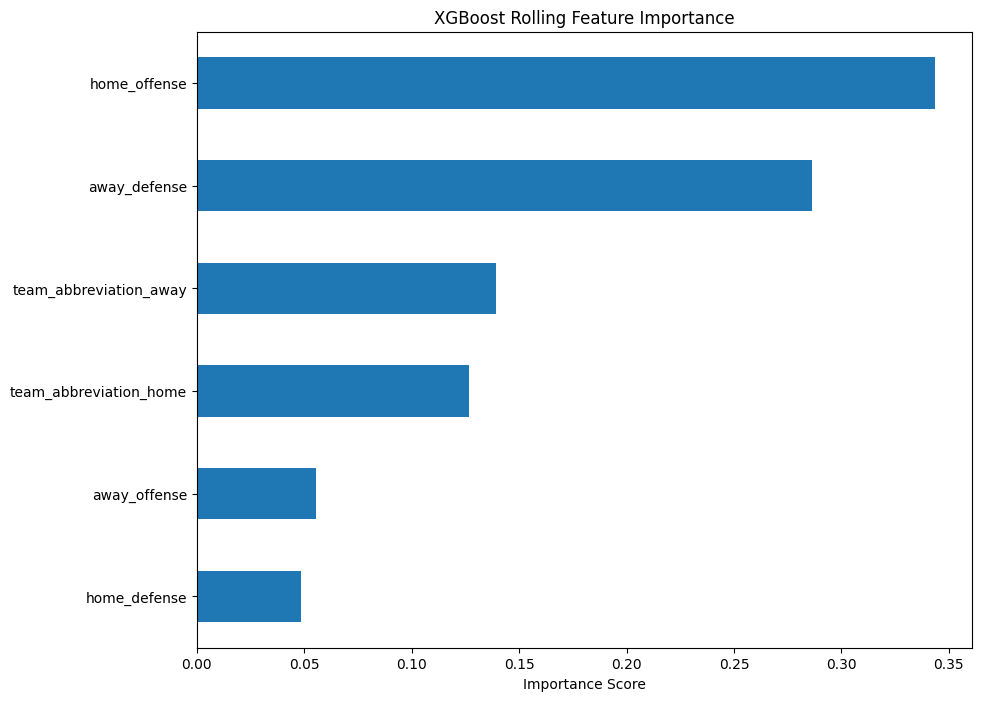


----- EQUITY CURVE -----


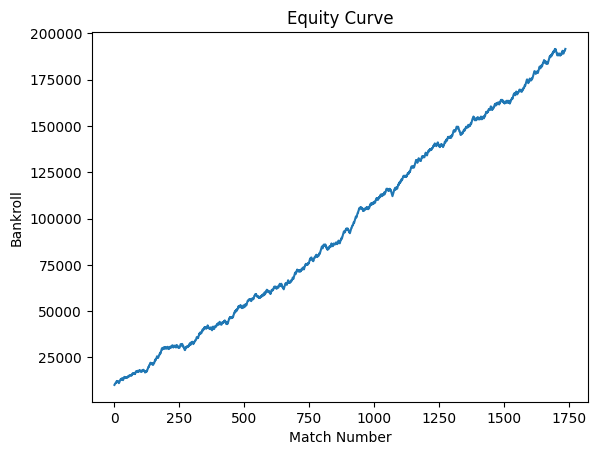


----- DRAWDOWN -----


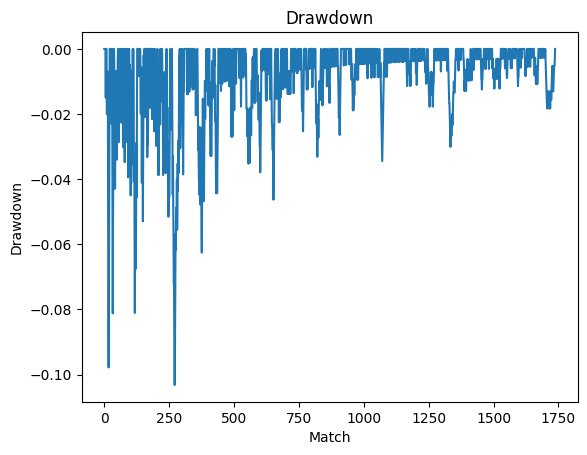


----- ROLLING SHARPE -----


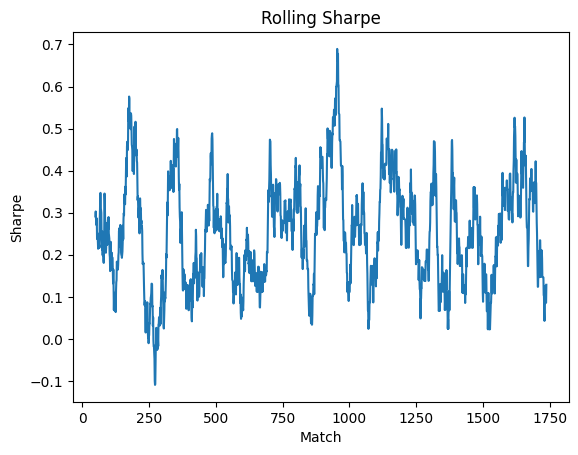


----- EDGE DISTRIBUTION -----


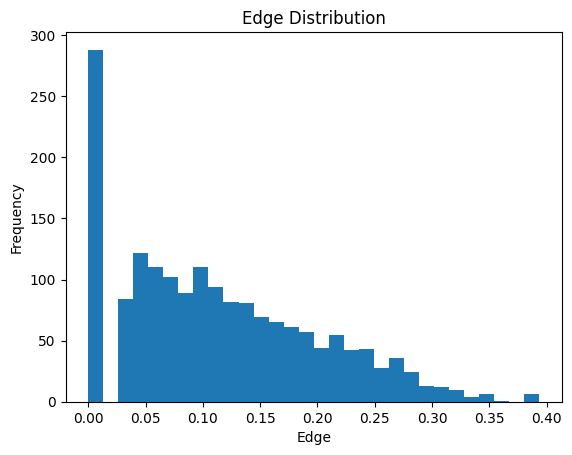


----- PROFIT BY EDGE BUCKET -----


C:\Users\Girisha\AppData\Local\Temp\ipykernel_61060\702688763.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("Edge_Bucket")["Profit"].mean()


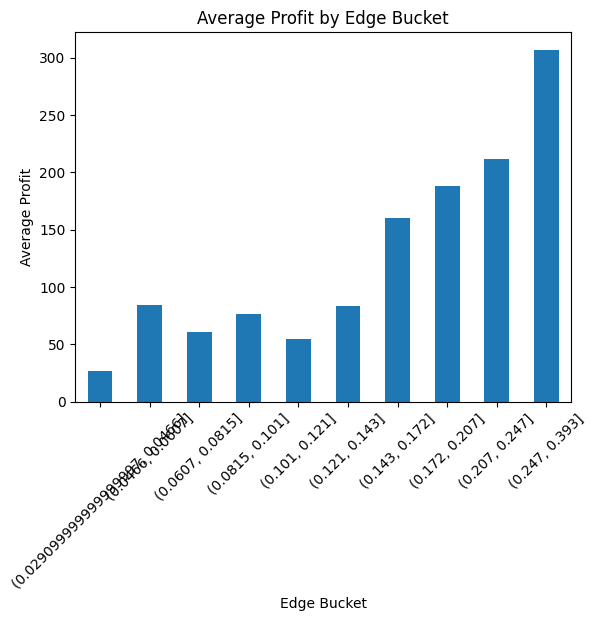


----- BET FREQUENCY -----


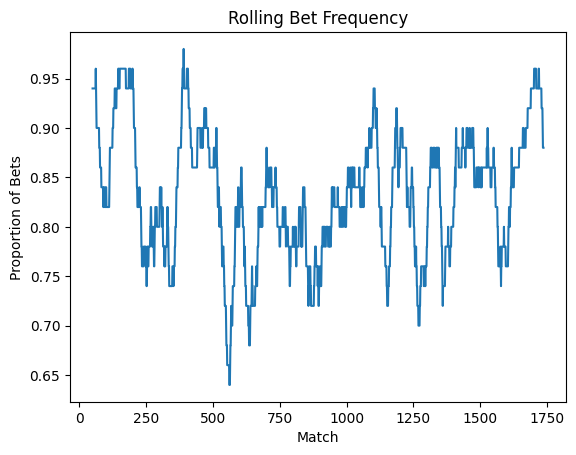

In [19]:
results = backtest(df_test_final, poisson_probability_function, bankroll_start=10000,kelly_scale=0.3, min_edge=0.03)
run_metrics(results, 10000)
run_plots_integrated(results)

In [20]:
team_lookup = df[['team_id_home', 'team_abbreviation_home']].drop_duplicates()
team_lookup.columns = ['team_id', 'team_abbreviation']
all_perf = all_perf.merge(team_lookup, on='team_id', how='left')

def manual_bet_interface(bankroll=10000,
                         kelly_scale=0.3,
                         min_edge=0.03,
                         max_fraction=0.05,
                         max_bet=500):
    
    home_team = input("Home Team: ").upper()
    away_team = input("Away Team: ").upper()
    
    home_odds = float(input(f"Odds for {home_team}: "))
    away_odds = float(input(f"Odds for {away_team}: "))
 

    try:
        h_stats = all_perf[all_perf['team_abbreviation'] == home_team].iloc[-1]
        a_stats = all_perf[all_perf['team_abbreviation'] == away_team].iloc[-1]
    except IndexError:
        print(f"ERROR: Could not find rolling stats for {home_team} or {away_team}.")
        return None
    row = {
        "team_abbreviation_home": home_team,
        "team_abbreviation_away": away_team,
        "home_offense": h_stats['roll_off'],
        "home_defense": h_stats['roll_def'],
        "away_offense": a_stats['roll_off'],
        "away_defense": a_stats['roll_def']
    }
    
    probabilities = poisson_probability_function(row)
    
    odds = {
        "Home": home_odds,
        "Away": away_odds
    }
    
    decision = choose_bet(
        probabilities,
        odds,
        bankroll,
        kelly_scale,
        min_edge,
        max_fraction,
        max_bet=max_bet
    )
    
    print("\n----- MODEL OUTPUT -----")
    print(f"Projected Stats: {home_team} Off {row['home_offense']:.1f} vs {away_team} Off {row['away_offense']:.1f}")
    print(f"Model Probabilities: Home {probabilities['Home']:.2%}, Away {probabilities['Away']:.2%}")
    print("Decision:", decision)
    
    return decision

In [21]:
manual_bet_interface()

ERROR: Could not find rolling stats for MEM or NEB.


Save Lamda Values to a file

In [23]:
import itertools

def save_lamdas(df, model_h, model_a):
    # get the most recent rolling stats for every team
    latest_stats_df = all_perf.sort_values('game_date').drop_duplicates('team_id', keep='last')
    
    id_to_abbr = pd.concat([
        df[['team_id_home', 'team_abbreviation_home']].rename(columns={'team_id_home':'id', 'team_abbreviation_home':'abbr'}),
        df[['team_id_away', 'team_abbreviation_away']].rename(columns={'team_id_away':'id', 'team_abbreviation_away':'abbr'})
    ]).drop_duplicates('id').set_index('id')['abbr'].to_dict()

    latest_stats = {}
    for _, row in latest_stats_df.iterrows():
        team_id = row['team_id']
        if team_id in id_to_abbr:
            latest_stats[id_to_abbr[team_id]] = {
                'off': row['roll_off'],
                'def': row['roll_def']
            }

    active_teams = list(latest_stats.keys())
    predictions = []

    for home_abbr, away_abbr in itertools.permutations(active_teams, 2):
  
        input_row = pd.DataFrame([{
            'team_abbreviation_home': home_abbr,
            'team_abbreviation_away': away_abbr,
            'home_offense': latest_stats[home_abbr]['off'],
            'home_defense': latest_stats[home_abbr]['def'],
            'away_offense': latest_stats[away_abbr]['off'],
            'away_defense': latest_stats[away_abbr]['def']
        }])

        input_row['team_abbreviation_home'] = input_row['team_abbreviation_home'].astype('category')
        input_row['team_abbreviation_away'] = input_row['team_abbreviation_away'].astype('category')
        lh = model_h.predict(input_row)[0]
        la = model_a.predict(input_row)[0]
        prob = win_prob(lh, la)
        predictions.append({
            'team_abbreviation_home': home_abbr,
            'team_abbreviation_away': away_abbr,
            'lambda_h': round(float(lh), 2),
            'lambda_a': round(float(la), 2),
            'win_prob': round(float(prob), 4),
            'projected_spread': round(float(la - lh), 1) # Positive means Home is favored
        })
    master_df = pd.DataFrame(predictions)
    master_df.to_csv("consensus_imports/poisson_lamdas.csv", index=False)
save_lamdas(df, model_home, model_away)

Future considerations:    
     - Use opponent adjusted statistics      
     - Add a feature to track the number of possessions in a game (on which goals scored are heavily dependant)    
     - Adding consideration for rest Days 